# Home assignment #3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Загрузка данных

In [2]:
imu = pd.read_csv("all_data.csv")

t  = imu["t"].values         
ax = imu["ax"].values
ay = imu["ay"].values
az = imu["az"].values
gx = imu["gx"].values         
gy = imu["gy"].values
gz = imu["gz"].values

dt = np.diff(t, prepend=t[0])
dt[0] = dt[1]

# Пример данных
imu

,t,ax,ay,az,gx,gy,gz
0,0.015788,0.025125,0.061615,9.860224,0.000611,0.004123,-0.000000
1,0.017890,0.010768,0.066401,9.802796,0.000611,0.004123,-0.000000
2,0.019990,0.001795,0.085543,9.759726,0.000611,0.004123,-0.000000
3,0.022089,0.001795,0.075972,9.754940,0.000611,0.004123,-0.000000
4,0.024198,-0.002991,0.071186,9.759128,-0.000611,-0.001985,-0.000000
...,...,...,...,...,...,...,...
27035,57.822904,0.011366,0.061615,9.816555,0.000458,-0.000764,0.001069
27036,57.825043,0.006580,0.071186,9.830912,-0.000764,0.001680,-0.000153
27037,57.827155,0.011366,0.080758,9.835697,-0.000764,0.000458,-0.000153
27038,57.829318,0.011366,0.080758,9.835697,0.000458,0.000458,-0.000153


## Метод A. Euler-based EKF

In [3]:
def euler_process_model(x, omega, dt):
    roll, pitch, yaw = x
    wx, wy, wz = omega

    # Матрица перехода от body-угл.скоростей к угл.скоростям Эйлера
    sr, cr = np.sin(roll), np.cos(roll)
    tp = np.tan(pitch)
    cp = np.cos(pitch)

    roll_dot  = wx + np.sin(roll)*np.tan(pitch)*wy + np.cos(roll)*np.tan(pitch)*wz
    pitch_dot =       np.cos(roll)          *wy - np.sin(roll)          *wz
    yaw_dot   = np.sin(roll)/cp*wy + np.cos(roll)/cp*wz

    roll_new  = roll  + roll_dot  * dt
    pitch_new = pitch + pitch_dot * dt
    yaw_new   = yaw   + yaw_dot   * dt

    return np.array([roll_new, pitch_new, yaw_new])


def euler_measurement_model(x):
    roll, pitch, yaw = x
    sr, cr = np.sin(roll), np.cos(roll)
    sp, cp = np.sin(pitch), np.cos(pitch)
    sy, cy = np.sin(yaw), np.cos(yaw)

    # rotation ZYX: R = Rz(yaw) * Ry(pitch) * Rx(roll)
    g = 9.81
    gx_b = -g * sp
    gy_b =  g * sr * cp
    gz_b =  g * cr * cp

    return np.array([gx_b, gy_b, gz_b])

In [4]:
def numerical_jacobian_f(f, x, omega, dt, eps=1e-5):
    n = len(x)
    J = np.zeros((n, n))
    fx = f(x, omega, dt)
    for i in range(n):
        x_pert = x.copy()
        x_pert[i] += eps
        J[:, i] = (f(x_pert, omega, dt) - fx) / eps
    return J

def numerical_jacobian_h(h, x, eps=1e-5):
    m = len(h(x))
    n = len(x)
    J = np.zeros((m, n))
    hx = h(x)
    for i in range(n):
        x_pert = x.copy()
        x_pert[i] += eps
        J[:, i] = (h(x_pert) - hx) / eps
    return J

In [5]:
def run_euler_ekf(t, ax, ay, az, gx, gy, gz):
    N = len(t)
    x = np.zeros(3)
    P = np.eye(3) * 0.1

    Q = np.eye(3) * 0.01   
    R = np.eye(3) * 0.5    

    xs = np.zeros((N, 3))

    for k in range(N):
        dt_k = dt[k]
        omega_k = np.array([gx[k], gy[k], gz[k]])
        z_k = np.array([ax[k], ay[k], az[k]])

        Fk = numerical_jacobian_f(euler_process_model, x, omega_k, dt_k)
        x_pred = euler_process_model(x, omega_k, dt_k)
        P_pred = Fk @ P @ Fk.T + Q

        Hk = numerical_jacobian_h(euler_measurement_model, x_pred)
        z_pred = euler_measurement_model(x_pred)
        y_k = z_k - z_pred
        S_k = Hk @ P_pred @ Hk.T + R
        K_k = P_pred @ Hk.T @ np.linalg.inv(S_k)

        x = x_pred + K_k @ y_k
        P = (np.eye(3) - K_k @ Hk) @ P_pred

        xs[k] = x

    return xs  # roll, pitch, yaw в рад

In [6]:
euler_angles = run_euler_ekf(t, ax, ay, az, gx, gy, gz)
roll_e, pitch_e, yaw_e = euler_angles.T

## Метод B. Quaternion-based EKF

In [7]:
def quat_normalize(q):
    return q / np.linalg.norm(q)

def omega_to_quat(omega):
    return np.array([0.0, omega[0], omega[1], omega[2]])

def quat_mult(q1, q2):
    w1,x1,y1,z1 = q1
    w2,x2,y2,z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

def quat_process_model(q, omega, dt):
    omega_q = omega_to_quat(omega)
    dq = 0.5 * quat_mult(q, omega_q) * dt
    q_new = q + dq
    return quat_normalize(q_new)

def quat_to_euler(q):
    w,x,y,z = q
    # roll (x)
    sinr_cosp = 2*(w*x + y*z)
    cosr_cosp = 1 - 2*(x*x + y*y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)
    # pitch (y)
    sinp = 2*(w*y - z*x)
    if abs(sinp) >= 1:
        pitch = np.sign(sinp) * (np.pi/2)
    else:
        pitch = np.arcsin(sinp)
    # yaw (z)
    siny_cosp = 2*(w*z + x*y)
    cosy_cosp = 1 - 2*(y*y + z*z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)
    return np.array([roll, pitch, yaw])

def quat_measurement_model(q):
    roll, pitch, yaw = quat_to_euler(q)
    return euler_measurement_model(np.array([roll, pitch, yaw]))

In [8]:
def numerical_jacobian_f_quat(f, q, omega, dt, eps=1e-5):
    n = len(q)
    J = np.zeros((n, n))
    fq = f(q, omega, dt)
    for i in range(n):
        q_pert = q.copy()
        q_pert[i] += eps
        q_pert = quat_normalize(q_pert)
        J[:, i] = (f(q_pert, omega, dt) - fq) / eps
    return J

def numerical_jacobian_h_quat(h, q, eps=1e-5):
    m = len(h(q))
    n = len(q)
    J = np.zeros((m, n))
    hq = h(q)
    for i in range(n):
        q_pert = q.copy()
        q_pert[i] += eps
        q_pert = quat_normalize(q_pert)
        J[:, i] = (h(q_pert) - hq) / eps
    return J

In [9]:
def run_quat_ekf(t, ax, ay, az, gx, gy, gz):
    N = len(t)
    # начальное состояние: единичный кватернион
    q = np.array([1.0, 0.0, 0.0, 0.0])
    P = np.eye(4) * 0.1

    Q = np.eye(4) * 0.001
    R = np.eye(3) * 0.5

    qs = np.zeros((N, 4))
    norms_before_norm = np.zeros(N)

    for k in range(N):
        dt_k = dt[k]
        omega_k = np.array([gx[k], gy[k], gz[k]])
        z_k = np.array([ax[k], ay[k], az[k]])

        Fk = numerical_jacobian_f_quat(quat_process_model, q, omega_k, dt_k)
        q_pred = quat_process_model(q, omega_k, dt_k)
        q_raw = q + 0.5 * quat_mult(q, omega_to_quat(omega_k)) * dt_k
        norms_before_norm[k] = np.linalg.norm(q_raw)

        P_pred = Fk @ P @ Fk.T + Q

        Hk = numerical_jacobian_h_quat(quat_measurement_model, q_pred)
        z_pred = quat_measurement_model(q_pred)
        y_k = z_k - z_pred
        S_k = Hk @ P_pred @ Hk.T + R
        K_k = P_pred @ Hk.T @ np.linalg.inv(S_k)

        dq = K_k @ y_k
        q = q_pred + dq
        q = quat_normalize(q) 
        P = (np.eye(4) - K_k @ Hk) @ P_pred

        qs[k] = q

    return qs, norms_before_norm

In [10]:
quats, quat_norms_raw = run_quat_ekf(t, ax, ay, az, gx, gy, gz)
euler_from_quat = np.array([quat_to_euler(q) for q in quats])
roll_q, pitch_q, yaw_q = euler_from_quat.T

## Анализ и визуализация

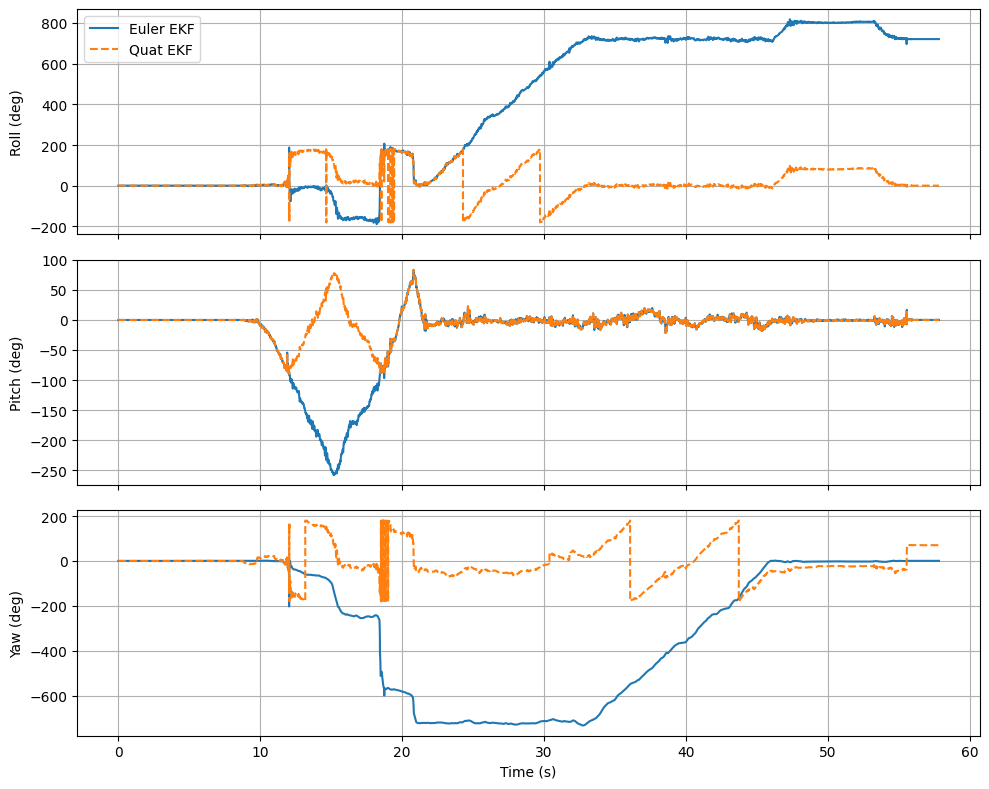

In [11]:
# Roll, Pitch, Yaw — Euler vs Quaternion
time_s = t

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(time_s, np.degrees(roll_e), label="Euler EKF")
axs[0].plot(time_s, np.degrees(roll_q), label="Quat EKF", linestyle="--")
axs[0].set_ylabel("Roll (deg)")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(time_s, np.degrees(pitch_e), label="Euler EKF")
axs[1].plot(time_s, np.degrees(pitch_q), label="Quat EKF", linestyle="--")
axs[1].set_ylabel("Pitch (deg)")
axs[1].grid(True)

axs[2].plot(time_s, np.degrees(yaw_e), label="Euler EKF")
axs[2].plot(time_s, np.degrees(yaw_q), label="Quat EKF", linestyle="--")
axs[2].set_ylabel("Yaw (deg)")
axs[2].set_xlabel("Time (s)")
axs[2].grid(True)

plt.tight_layout()
plt.show()

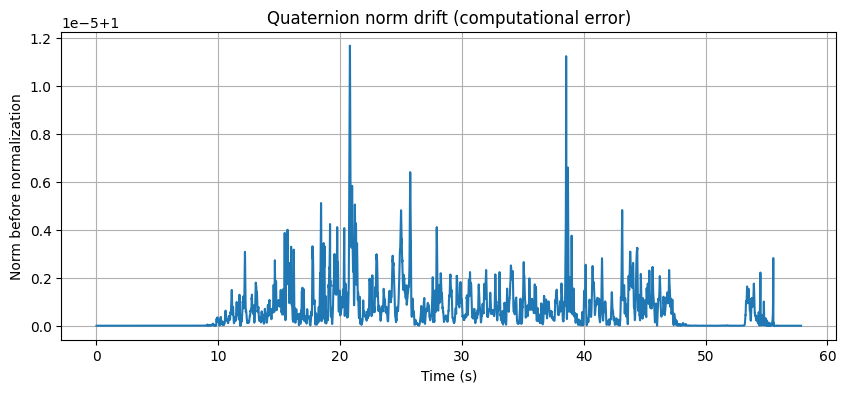

In [12]:
# Quaternion norm drift
plt.figure(figsize=(10, 4))
plt.plot(time_s, quat_norms_raw)
plt.xlabel("Time (s)")
plt.ylabel("Norm before normalization")
plt.title("Quaternion norm drift (computational error)")
plt.grid(True)
plt.show()